In [1]:
# Load necessary library
library(fs)
library("ggplot2")
library("dplyr")



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
# Define base directories for the two nested directories
beta_dir1 <- "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta"  # Theoretical
kingman_dir2 <- "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_kingman"  # Empirical

# List only directories in beta_dir1 that are two levels deep
beta_subdirs1 <- list.dirs(beta_dir1, recursive = TRUE, full.names = TRUE)
beta_subdirs1 <- beta_subdirs1[sapply(strsplit(beta_subdirs1, "/"), length) == length(strsplit(beta_dir1, "/")[[1]]) + 2]

# List only directories in kingman_dir2 that are one level deep
kingman_subdirs2 <- list.dirs(kingman_dir2, recursive = TRUE, full.names = TRUE)
kingman_subdirs2 <- kingman_subdirs2[sapply(strsplit(kingman_subdirs2, "/"), length) == length(strsplit(kingman_dir2, "/")[[1]]) + 1]

# Initialize a list to store matches
matches <- list()

# Loop through each theoretical directory
for (beta_dir in beta_subdirs1) {
  # Get the second-to-last directory name (e.g., "m1e-10")
  second_last_dir <- dirname(beta_dir)  # Get the parent directory
  second_to_last_beta_dir <- basename(second_last_dir)  # This gets the second-to-last directory name
  
  # Find matching empirical directories based on the last directory name
  matching_dirs <- kingman_subdirs2[grepl(second_to_last_beta_dir, kingman_subdirs2)]
  
  # If there are matching empirical directories, store them in a structured way
  if (length(matching_dirs) > 0) {
    for (kingman_dir in matching_dirs) {
      # Initialize list if it doesn't exist
      if (!is.null(matches[[kingman_dir]])) {
        matches[[kingman_dir]] <- c(matches[[kingman_dir]], beta_dir)
      } else {
        matches[[kingman_dir]] <- list(beta_dir)
      }
    }
  }
}

# Format the output for better readability
formatted_matches <- lapply(names(matches), function(kingman) {
  list(
    kingman = kingman,
    beta_dirs = matches[[kingman]]
  )
})

# Display the summarized matches
print("Summarized Matches:")
print(formatted_matches)


[1] "Summarized Matches:"
[[1]]
[[1]]$kingman
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_kingman/m1e-10"

[[1]]$beta_dirs
[[1]]$beta_dirs[[1]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-10/alpha1.3"

[[1]]$beta_dirs[[2]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-10/alpha1.5"

[[1]]$beta_dirs[[3]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-10/alpha1.7"

[[1]]$beta_dirs[[4]]
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-10/alpha1.9"



[[2]]
[[2]]$kingman
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_kingman/m1e-6"

[[2]]$beta_dirs
[[2]]$beta_dirs[[1]

In [15]:
# Initialize a list to store the paths of .rds files
rds_files_list <- list()

# Loop through each matched directory
for (i in seq_along(formatted_matches)) {
  # Get the kingman directory
  kingman_dir <- formatted_matches[[i]]$kingman
  rds_files_kingman <- list.files(path = kingman_dir, pattern = "\\.rds$", full.names = TRUE)
  
  # Get the beta directories
  beta_dirs <- formatted_matches[[i]]$beta_dirs
  rds_files_beta <- unlist(lapply(beta_dirs, function(beta_dir) {
    list.files(path = beta_dir, pattern = "\\.rds$", full.names = TRUE)
  }))
  
  # Store the results in the list
  rds_files_list[[i]] <- list(
    kingman = rds_files_kingman,
    beta_dirs = rds_files_beta
  )
}

# Print the list of .rds files
print(rds_files_list)

[[1]]
[[1]]$kingman
 [1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_kingman/m1e-10/Kingman_bottleneck_rep0_m1e-10_ratio999.9999999999999_rs1525225.vcf.rds"
 [2] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_kingman/m1e-10/Kingman_bottleneck_rep1_m1e-10_ratio999.9999999999999_rs1525226.vcf.rds"
 [3] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_kingman/m1e-10/Kingman_bottleneck_rep2_m1e-10_ratio999.9999999999999_rs1525227.vcf.rds"
 [4] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_kingman/m1e-10/Kingman_bottleneck_rep3_m1e-10_ratio999.9999999999999_rs1525228.vcf.rds"
 [5] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_kingman/m1e-10/Kingman_bottleneck_rep4_m1e-10_ratio999.99999999

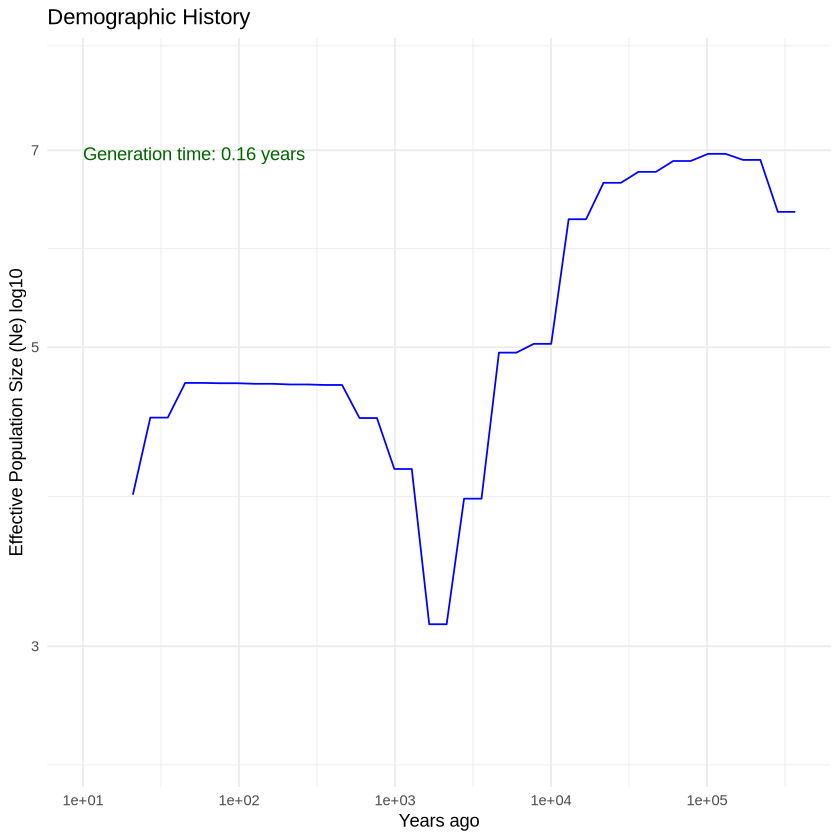

In [14]:

# Provided demography data
demography_data <- data.frame(
  years_ago = c(20.90991, 27.04340, 34.97601, 45.23550, 58.50439,
                75.66543, 97.86030, 126.56557, 163.69094, 211.70625,
                273.80586, 354.12109, 457.99511, 592.33841, 766.08851,
                990.80457, 1281.43640, 1657.31899, 2143.45890, 2772.19779,
                3585.36410, 4637.05576, 5997.23919, 7756.40403, 10031.58311,
                12974.13845, 16779.83093, 21701.84380, 28067.62632, 36300.67815,
                46948.72375, 60720.15108, 78531.13893, 101566.60798, 131359.05066,
                169890.48403, 219724.30843, 284175.84417, 367532.89150),
  Ne_log10 = c(3.886466, 4.433363, 4.433363, 4.704220, 4.704220,
               4.701291, 4.701291, 4.696954, 4.696954, 4.691536,
               4.691536, 4.687589, 4.687589, 4.430142, 4.430142,
               4.060712, 4.060712, 3.114804, 3.114804, 3.860018,
               3.860018, 4.953656, 4.953656, 5.028866, 5.028866,
               6.221847, 6.221847, 6.621246, 6.621246, 6.746056,
               6.746056, 6.872533, 6.872533, 6.957109, 6.957109,
               6.885372, 6.885372, 6.300497, 6.300497)
)

# Convert years_ago to generations_ago (assuming generation time of 0.16 years)

# Convert Ne_log10 to actual Ne values

# Plotting using ggplot2
ggplot(demography_data, aes(x = years_ago, y = Ne_log10)) +
  geom_line(color = "blue") +
  scale_x_log10() +
  scale_y_log10(limits = c(2.5, 8)) +  # Adjusting y-axis limits
  labs(title = "Demographic History",
       x = "Years ago",
       y = "Effective Population Size (Ne) log10") +
  theme_minimal() +
  annotate("text", x = 10, y = max(demography_data$Ne_log10, na.rm = TRUE), 
           label = "Generation time: 0.16 years", hjust = 0, color = "darkgreen")


In [10]:
str(rds_files_list)

List of 5
 $ :List of 2
  ..$ kingman  : chr [1:10] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_king"| __truncated__ "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_king"| __truncated__ "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_king"| __truncated__ "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_king"| __truncated__ ...
  ..$ beta_dirs: chr [1:21] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta"| __truncated__ "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta"| __truncated__ "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta"| __truncated__ "/data/proj2/

In [21]:
# Constants
mu <- 1e-06
gen_times <-0.16

# Initialize a list to store individual data frames with hierarchical structure
individual_data_frames <- vector("list", length(rds_files_list))


# Initialize sub-lists for 'kingman' and 'beta' within each main entry
individual_data_frames[[1]] <- list(kingman = list(), beta = list())
  
# Process 'kingman' files
for (j in seq_along(rds_files_list[[2]]$kingman)) {
    kingman_dir <- rds_files_list[[2]]$kingman[j]
    
    if (file.exists(kingman_dir)) {
      data_esmc <- readRDS(kingman_dir)  # Read the .rds file
      
      # Perform calculations
      Ne_t <- data_esmc$Xi
      Ne <- mean(data_esmc$mu / mu)

      # Calculate years ago and log10 of Ne
      data_esmc$years_ago <- data_esmc$Tc * Ne * gen_times
      data_esmc$Ne <- log10(Ne_t * Ne)
      
      # Create a unique label using both j and file_base_name
      file_base_name <- basename(kingman_dir)
      label <- paste0(j, "_", file_base_name)
      
      # Store the results in a data frame using the unique label
      individual_data_frames[[1]]$kingman[[label]] <- data.frame(
        years_ago = data_esmc$years_ago,
        Ne = data_esmc$Ne
      )
    } else {
      warning(paste("Kingman directory does not exist:", kingman_dir))
    }
  }
  
  # Process 'beta' files
  for (j in seq_along(rds_files_list[[2]]$beta)) {
    beta_dir <- rds_files_list[[2]]$beta[j]
    #split path
    path_components <- unlist(strsplit(beta_dir, "/"))
    # Extract the second last component
    second_last_component <- path_components[length(path_components) - 1]
    if (file.exists(beta_dir)) {
      data_esmc <- readRDS(beta_dir)  # Read the .rds file

      # Perform calculations
      Ne_t <- data_esmc$Xi
      Ne <- mean(data_esmc$mu / mu)
      
      # Calculate years ago and log10 of Ne
      data_esmc$years_ago <- data_esmc$Tc * Ne * gen_times
      data_esmc$Ne <- log10(Ne_t * Ne)
      
      # Create a unique label using both j and file_base_name
      file_base_name <- basename(beta_dir)
      label <- paste0(j, "_",file_base_name)
      # Store the results in a data frame using the unique label
      individual_data_frames[[1]]$beta[[label]] <- data.frame(
        years_ago = data_esmc$years_ago,
        Ne = data_esmc$Ne,
        alpha=as.character(second_last_component)
      )
    } else {
      warning(paste("Beta directory does not exist:", beta_dir))
    }
}

# Create a color palette for the alpha values
alpha_values <- unique(unlist(lapply(individual_data_frames[[1]]$beta, function(df) df$alpha)))
colors <- rainbow(length(alpha_values))  # Generate colors for each alpha


In [30]:
names(individual_data_frames[[1]]$beta[1])

[1] "1_Beta_bottleneck_rep0_m1e-06_ratio0.1_rs1525225.vcf.rds"

In [22]:
# Reshape and combine beta data for all alphas
all_beta_lines <- lapply(seq_along(individual_data_frames[[1]]$beta), function(i) {
  df <- individual_data_frames[[1]]$beta[[i]]
  rep_name <- names(individual_data_frames[[1]]$beta)[i]  # Get the name of the current beta data frame
  df %>%
    mutate(alpha = df$alpha[1],  # Add alpha column
           Rep = rep_name)       # Add Rep column with the current name
}) %>% bind_rows()  # Combine all beta data frames into one



In [72]:
head(demography_data)

,years_ago,Ne_log10
,<dbl>,<dbl>
1,20.90991,3.886466
2,27.04340,4.433363
3,34.97601,4.433363
4,45.23550,4.704220
5,58.50439,4.704220
6,75.66543,4.701291


Warning message in scale_x_log10(limits = c(0.1, 5e+05), breaks = scales::log_breaks()):
“log-10 transformation introduced infinite values.”


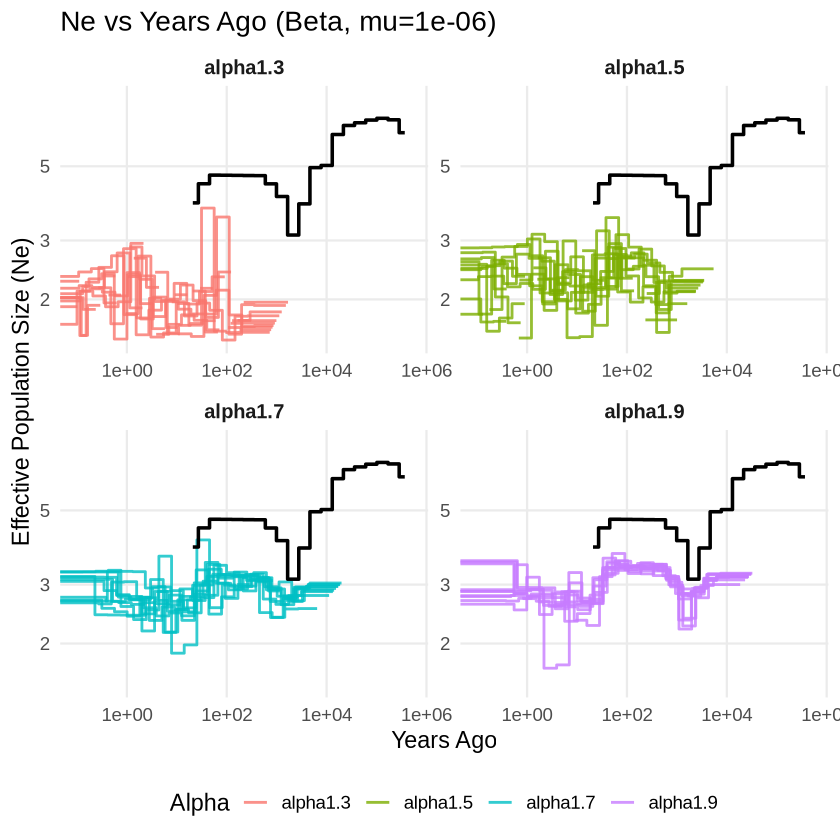

In [23]:
# Create the step plot with facets
gg <- ggplot() +
  # Add step lines for beta data (color by alpha, group by Rep)
  geom_step(data = all_beta_lines,
            aes(x = years_ago, y = Ne, group = Rep, color = as.factor(alpha)),
            size = 0.8, alpha = 0.8) +
  # Add the overall demography line as a step plot in black for each facet
  geom_step(data = demography_data,
            aes(x = years_ago, y = Ne_log10),
            color = "black", size = 1.0) +
  # Set axes to log scale
  scale_x_log10(limits = c(0.1, 500000), breaks = scales::log_breaks()) +
  scale_y_log10(limits = c(1.5, 8), breaks = scales::log_breaks()) +
  # Use facet_wrap to create lattice-style subplots by alpha
  facet_wrap(~ alpha, scales = "free", ncol = 2) +
  # Add labels and theme
  labs(
    x = "Years Ago",
    y = "Effective Population Size (Ne)",
    color = "Alpha",
    title = "Ne vs Years Ago (Beta, mu=1e-06)"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    strip.text = element_text(size = 12, face = "bold"),  # Facet labels
    legend.position = "bottom",
    panel.grid.minor = element_blank()
  )

# Print the ggplot
print(gg)


In [12]:
# Reshape and combine beta data for all alphas
all_kingman_lines <- lapply(seq_along(individual_data_frames[[1]]$kingman), function(i) {
  df <- individual_data_frames[[1]]$kingman[[i]]
  rep_name <- names(individual_data_frames[[1]]$kingman)[i]  # Get the name of the current beta data frame
  df %>%
    mutate(Rep = rep_name)       # Add Rep column with the current name
}) %>% bind_rows()  # Combine all beta data frames into one

head(all_kingman_lines)

,years_ago,Ne,Rep
,<dbl>,<dbl>,<chr>
1,0.0000,4.549257,1_Kingman_bottleneck_rep0_m1e-06_ratio0.1_rs1525225.vcf.rds
2,371.6391,4.549257,1_Kingman_bottleneck_rep0_m1e-06_ratio0.1_rs1525225.vcf.rds
3,497.6016,4.551454,1_Kingman_bottleneck_rep0_m1e-06_ratio0.1_rs1525225.vcf.rds
4,666.2573,4.551454,1_Kingman_bottleneck_rep0_m1e-06_ratio0.1_rs1525225.vcf.rds
5,892.0769,3.577030,1_Kingman_bottleneck_rep0_m1e-06_ratio0.1_rs1525225.vcf.rds
6,1194.4351,3.577030,1_Kingman_bottleneck_rep0_m1e-06_ratio0.1_rs1525225.vcf.rds


In [18]:
# Create the step plot with facets
gg <- ggplot() +
  # Add step lines for beta data (color by alpha, group by Rep)
  geom_step(data = all_kingman_lines,
            aes(x = years_ago, y = Ne, group = Rep, color = as.factor(alpha)),
            size = 0.8, alpha = 0.8) +
  # Add the overall demography line as a step plot in black
  geom_step(data = demography_data,
            aes(x = years_ago, y = Ne_log10),
            color = "black", size = 1.0) +
  # Set both axes to log scale
  scale_x_log10(limits = c(0.1, 500000), breaks = scales::log_breaks()) +
  scale_y_log10(limits = c(1.5, 8), breaks = scales::log_breaks()) +  # Log scale for y-axis
  # Use facet_wrap to create lattice-style subplots by alpha
  # Add labels and theme
  labs(
    x = "Years Ago",
    y = "Effective Population Size (Ne)",
    color = "Alpha",  # Label for color legend
    title = "Ne vs Years Ago (Beta, mu=1e-06)"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    strip.text = element_text(size = 12, face = "bold"),  # Facet labels
    legend.position = "bottom",
    panel.grid.minor = element_blank()
  )

# Print the ggplot
print(gg)




ERROR: [1m[33mError[39m in `geom_step()`:[22m
[1m[22m[33m![39m Problem while computing aesthetics.
[36mℹ[39m Error occurred in the 1st layer.
[1mCaused by error in `unique.default()`:[22m
[33m![39m unique() applies only to vectors


In [16]:
# Constants
mu <- 1e-07
gen_times <-0.16


# Initialize sub-lists for 'kingman' and 'beta' within each main entry
individual_data_frames[[2]] <- list(kingman = list(), beta = list())
  
# Process 'kingman' files
for (j in seq_along(rds_files_list[[3]]$kingman)) {
    kingman_dir <- rds_files_list[[3]]$kingman[j]
    
    if (file.exists(kingman_dir)) {
      data_esmc <- readRDS(kingman_dir)  # Read the .rds file
      
      # Perform calculations
      Ne_t <- data_esmc$Xi
      Ne <- mean(data_esmc$mu / mu)
      print(data_esmc$mu)
      # Calculate years ago and log10 of Ne
      data_esmc$years_ago <- data_esmc$Tc * Ne * gen_times
      data_esmc$Ne <- log10(Ne_t * Ne)
      
      # Create a unique label using both j and file_base_name
      file_base_name <- basename(kingman_dir)
      label <- paste0(j, "_", file_base_name)
      
      # Store the results in a data frame using the unique label
      individual_data_frames[[2]]$kingman[[label]] <- data.frame(
        years_ago = data_esmc$years_ago,
        Ne = data_esmc$Ne
      )
    } else {
      warning(paste("Kingman directory does not exist:", kingman_dir))
    }
  }
  
  # Process 'beta' files
  for (j in seq_along(rds_files_list[[3]]$beta)) {
    beta_dir <- rds_files_list[[3]]$beta[j]
    path_components <- unlist(strsplit(beta_dir, "/"))
    # Extract the second last component
    second_last_component <- path_components[length(path_components) - 1]
    if (file.exists(beta_dir)) {
      data_esmc <- readRDS(beta_dir)  # Read the .rds file

      # Perform calculations
      Ne_t <- data_esmc$Xi
      Ne <- mean(data_esmc$mu / mu)
      
      # Calculate years ago and log10 of Ne
      data_esmc$years_ago <- data_esmc$Tc * Ne * gen_times
      data_esmc$Ne <- log10(Ne_t * Ne)
      
      # Create a unique label using both j and file_base_name
      file_base_name <- basename(beta_dir)
      label <- paste0(j, "_",file_base_name)
      # Store the results in a data frame using the unique label
      individual_data_frames[[2]]$beta[[label]] <- data.frame(
        years_ago = data_esmc$years_ago,
        Ne = data_esmc$Ne,
        alpha=as.character(second_last_component)
      )
    } else {
      warning(paste("Beta directory does not exist:", beta_dir))
    }
}



[1] 0.0008879016
[1] 0.0009550081
[1] 0.0008588239
[1] 0.0009784057
[1] 0.001211165
[1] 0.000905437
[1] 0.0009060085
[1] 0.001119405
[1] 0.0009082562
[1] 0.0009548144


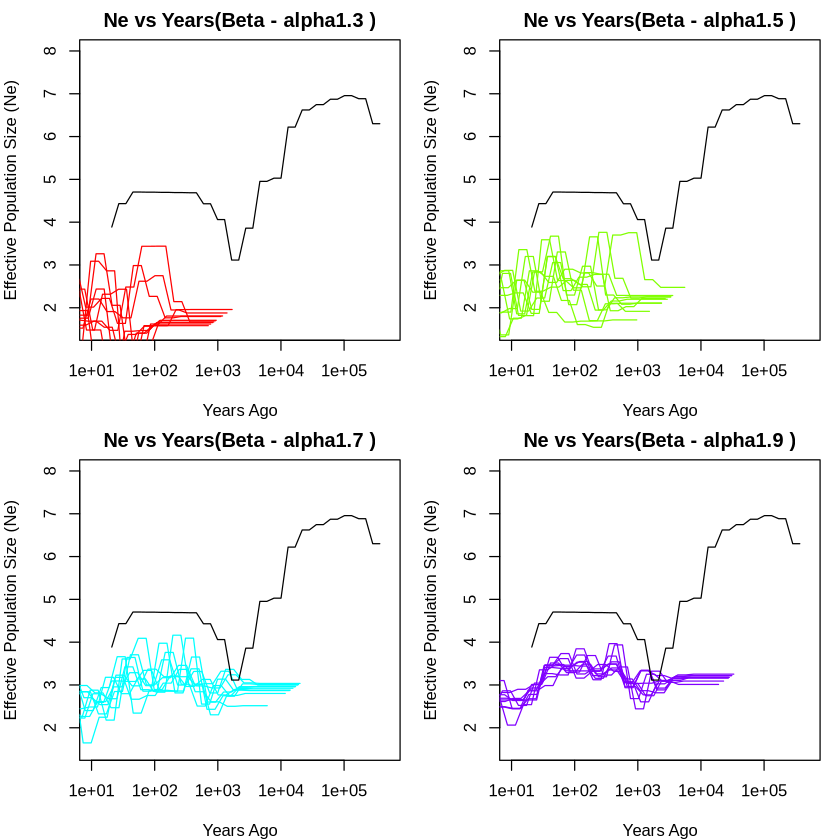

In [17]:
# # Define the number of rows and columns for subplots based on the number of alpha values
num_alphas <- length(alpha_values)
rows <- ceiling(sqrt(num_alphas))  # Number of rows for the plot grid
cols <- ceiling(num_alphas / rows) # Number of columns for the plot grid

# Set up layout for multiple subplots
par(mfrow = c(rows, cols), mar = c(4, 4, 2, 1),bg="white")  # Adjust margins for subplot spacing

# Loop over each alpha value and create individual plots
for (alpha in alpha_values) {
  # Set up empty plot for the current alpha
  plot(NULL, xlim = c(10, 500000), ylim = c(1.5, 8),
       xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
       main = paste("Ne vs Years(Beta -", alpha, ")"),
       log = "x")

  # Filter Beta data frames by the current alpha
  beta_lines <- lapply(individual_data_frames[[2]]$beta, function(df) {
    if (df$alpha[1] == alpha) {
      return(df)
    } else {
      return(NULL)
    }
  })
  beta_lines <- Filter(Negate(is.null), beta_lines)  # Remove NULL entries

  # Plot each line for the current alpha
  for (i in seq_along(beta_lines)) {
    lines(beta_lines[[i]]$years_ago, beta_lines[[i]]$Ne, 
          type = "l", lty = 1, col = colors[which(alpha_values == alpha)])
  }
  # Plot the overall demography line in black for each subplot
    lines((demography_data$years_ago), demography_data$Ne, 
        type = "l", lty = 1, col = "black")
}

# Reset layout to default for any further plots
par(mfrow = c(1, 1))

if Ne is underestimated then TMRCAs are underestimated

The TMRCA distribution (waiting time) tends to longer TMRCAs then old population sizes are larger 

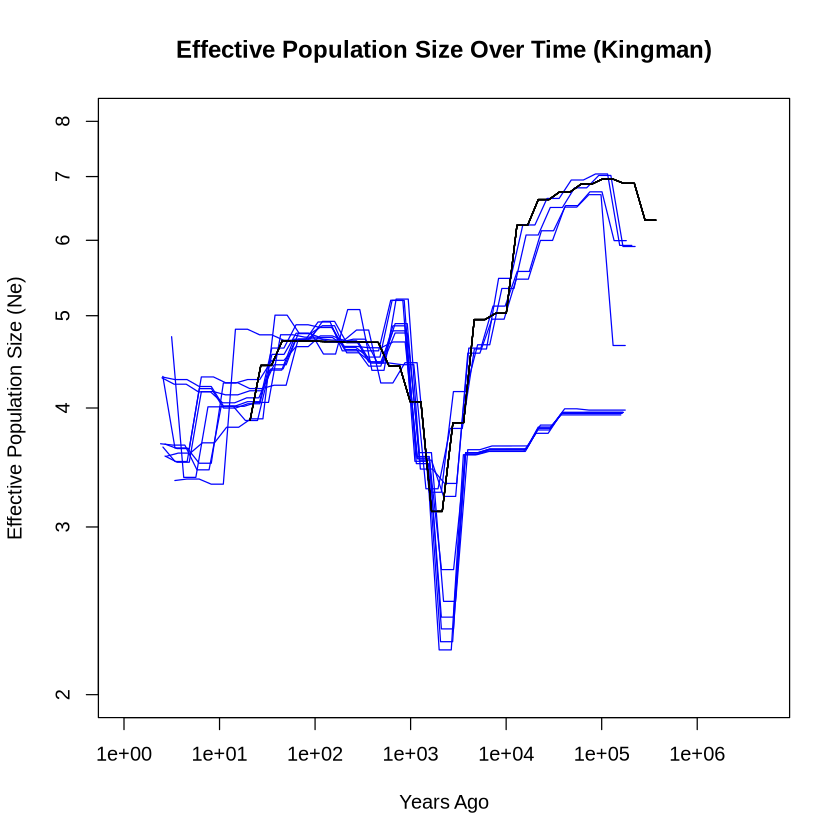

In [18]:
par(bg="white")
# Plot setup for Kingman lines
plot(NULL, xlim = c(1, 5000000), ylim = c(2, 8),
     xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
     main = "Effective Population Size Over Time (Kingman)",
     log = "xy")

# Plot Kingman lines for all items in individual_data_frames
for (i in seq_along(individual_data_frames[[2]]$kingman)) {
  lines(individual_data_frames[[2]]$kingman[[i]]$years_ago, 
        individual_data_frames[[2]]$kingman[[i]]$Ne, 
        type = "l", lty = 1, col = "blue")
          # Plot the overall demography line in black for each subplot
  lines(demography_data$years_ago, demography_data$Ne, 
        type = "l", lty = 1, col = "black")
}



m1e-08

In [15]:
# Constants
mu <- 1e-08
gen_times <-0.16

# Initialize sub-lists for 'kingman' and 'beta' within each main entry
individual_data_frames[[3]] <- list(kingman = list(), beta = list())
  
# Process 'kingman' files
for (j in seq_along(rds_files_list[[5]]$kingman)) {
    kingman_dir <- rds_files_list[[5]]$kingman[j]
    
    if (file.exists(kingman_dir)) {
      data_esmc <- readRDS(kingman_dir)  # Read the .rds file
      
      # Perform calculations
      Ne_t <- data_esmc$Xi
      Ne <- mean(data_esmc$mu / mu)

      # Calculate years ago and log10 of Ne
      data_esmc$years_ago <- data_esmc$Tc * Ne * gen_times
      data_esmc$Ne <- log10(Ne_t * Ne)
      
      # Create a unique label using both j and file_base_name
      file_base_name <- basename(kingman_dir)
      label <- paste0(j, "_", file_base_name)
      
      # Store the results in a data frame using the unique label
      individual_data_frames[[3]]$kingman[[label]] <- data.frame(
        years_ago = data_esmc$years_ago,
        Ne = data_esmc$Ne
      )
    } else {
      warning(paste("Kingman directory does not exist:", kingman_dir))
    }
  }
  
  # Process 'beta' files
  for (j in seq_along(rds_files_list[[5]]$beta)) {
    beta_dir <- rds_files_list[[5]]$beta[j]
    path_components <- unlist(strsplit(beta_dir, "/"))
    # Extract the second last component
    second_last_component <- path_components[length(path_components) - 1]
    if (file.exists(beta_dir)) {
      data_esmc <- readRDS(beta_dir)  # Read the .rds file

      # Perform calculations
      Ne_t <- data_esmc$Xi
      Ne <- mean(data_esmc$mu / mu)
      
      # Calculate years ago and log10 of Ne
      data_esmc$years_ago <- data_esmc$Tc * Ne * gen_times
      data_esmc$Ne <- log10(Ne_t * Ne)
      
      # Create a unique label using both j and file_base_name
      file_base_name <- basename(beta_dir)
      label <- paste0(j, "_",file_base_name)
      # Store the results in a data frame using the unique label
      individual_data_frames[[3]]$beta[[label]] <- data.frame(
        years_ago = data_esmc$years_ago,
        Ne = data_esmc$Ne,
        alpha=as.character(second_last_component)
      )
    } else {
      warning(paste("Beta directory does not exist:", beta_dir))
    }
}




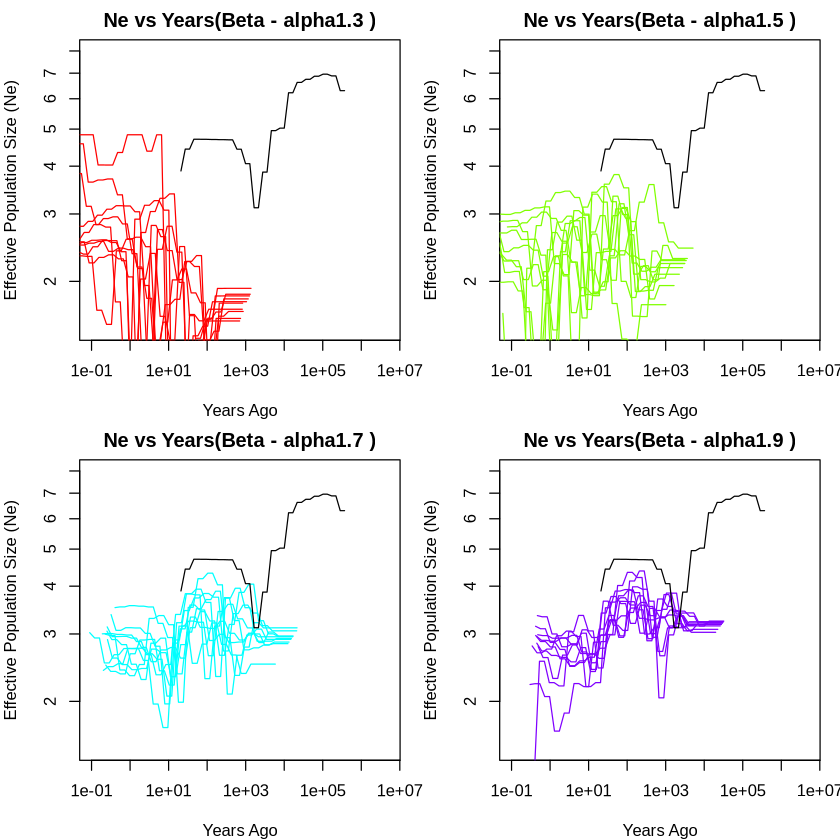

In [16]:
# # Define the number of rows and columns for subplots based on the number of alpha values
num_alphas <- length(alpha_values)
rows <- ceiling(sqrt(num_alphas))  # Number of rows for the plot grid
cols <- ceiling(num_alphas / rows) # Number of columns for the plot grid

# Set up layout for multiple subplots
par(mfrow = c(rows, cols), mar = c(4, 4, 2, 1), bg="white")  # Adjust margins for subplot spacing

# Loop over each alpha value and create individual plots
for (alpha in alpha_values) {
  # Set up empty plot for the current alpha
  plot(NULL, xlim = c(0.1, 5000000), ylim = c(1.5, 8),
       xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
       main = paste("Ne vs Years(Beta -", alpha, ")"),
       log = "xy")

  # Filter Beta data frames by the current alpha
  beta_lines <- lapply(individual_data_frames[[3]]$beta, function(df) {
    if (df$alpha[1] == alpha) {
      return(df)
    } else {
      return(NULL)
    }
  })
  beta_lines <- Filter(Negate(is.null), beta_lines)  # Remove NULL entries

  # Plot each line for the current alpha
  for (i in seq_along(beta_lines)) {
    lines(beta_lines[[i]]$years_ago, beta_lines[[i]]$Ne, 
          type = "l", lty = 1, col = colors[which(alpha_values == alpha)])
  }
  # Plot the overall demography line in black for each subplot
    lines(demography_data$years_ago, demography_data$Ne, 
        type = "l", lty = 1, col = "black")
}

# Reset layout to default for any further plots
par(mfrow = c(1, 1))


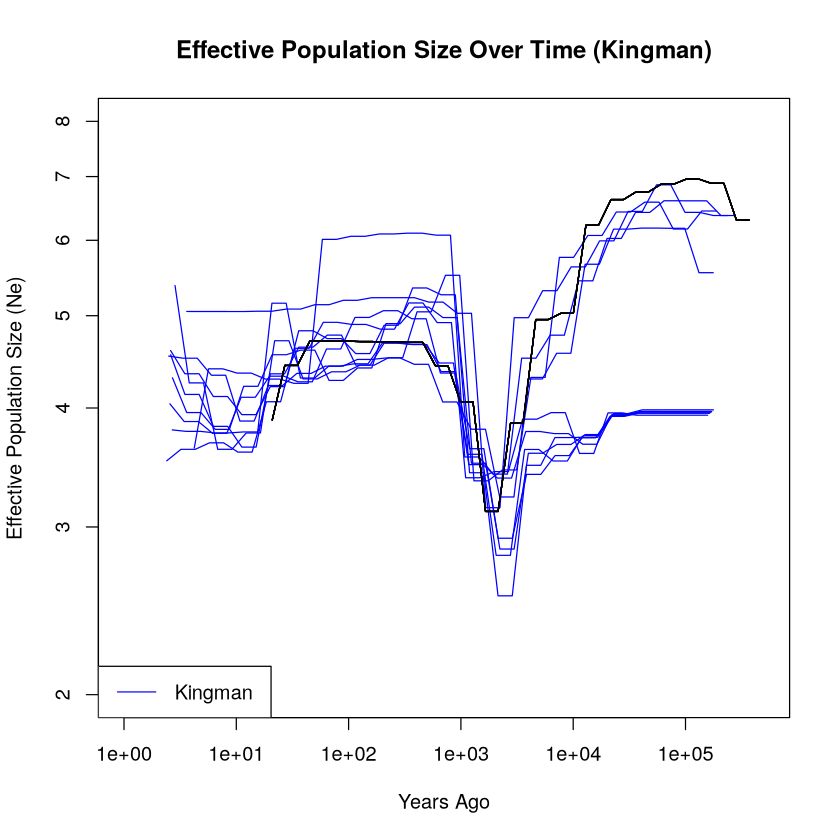

In [59]:


# Plot setup for Kingman lines
plot(NULL, xlim = c(1, 500000), ylim = c(2, 8),
     xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
     main = "Effective Population Size Over Time (Kingman)",
     log = "xy")

# Plot Kingman lines for all items in individual_data_frames
for (i in seq_along(individual_data_frames[[3]]$kingman)) {
  lines(individual_data_frames[[3]]$kingman[[i]]$years_ago, 
        individual_data_frames[[3]]$kingman[[i]]$Ne, 
        type = "l", lty = 1, col = "blue")
 # Plot the overall demography line in black for each subplot
    lines(demography_data$years_ago, demography_data$Ne, 
        type = "l", lty = 1, col = "black")       
}

# Add legend for Kingman lines
legend("bottomleft", legend = "Kingman", 
       col = "blue", lty = 1)




1e-09

In [25]:
# Constants
mu <- 1e-09
gen_times <-0.16

# Initialize sub-lists for 'kingman' and 'beta' within each main entry
individual_data_frames[[4]] <- list(kingman = list(), beta = list())
  
# Process 'kingman' files
for (j in seq_along(rds_files_list[[5]]$kingman)) {
    kingman_dir <- rds_files_list[[5]]$kingman[j]
    
    if (file.exists(kingman_dir)) {
      data_esmc <- readRDS(kingman_dir)  # Read the .rds file
      
      # Perform calculations
      Ne_t <- data_esmc$Xi
      Ne <- mean(data_esmc$mu / mu)

      # Calculate years ago and log10 of Ne
      data_esmc$years_ago <- data_esmc$Tc * Ne * gen_times
      data_esmc$Ne <- log10(Ne_t * Ne)
      
      # Create a unique label using both j and file_base_name
      file_base_name <- basename(kingman_dir)
      label <- paste0(j, "_", file_base_name)
      
      # Store the results in a data frame using the unique label
      individual_data_frames[[4]]$kingman[[label]] <- data.frame(
        years_ago = data_esmc$years_ago,
        Ne = data_esmc$Ne
      )
    } else {
      warning(paste("Kingman directory does not exist:", kingman_dir))
    }
  }
  
  # Process 'beta' files
  for (j in seq_along(rds_files_list[[5]]$beta)) {
    beta_dir <- rds_files_list[[5]]$beta[j]
    path_components <- unlist(strsplit(beta_dir, "/"))
    # Extract the second last component
    second_last_component <- path_components[length(path_components) - 1]
    if (file.exists(beta_dir)) {
      data_esmc <- readRDS(beta_dir)  # Read the .rds file

      # Perform calculations
      Ne_t <- data_esmc$Xi
      Ne <- mean(data_esmc$mu / mu)
      print(Ne)
      
      # Calculate years ago and log10 of Ne
      data_esmc$years_ago <- data_esmc$Tc * Ne * gen_times
      data_esmc$Ne <- log10(Ne_t * Ne)
      
      # Create a unique label using both j and file_base_name
      file_base_name <- basename(beta_dir)
      label <- paste0(j, "_",file_base_name)
      # Store the results in a data frame using the unique label
      individual_data_frames[[4]]$beta[[label]] <- data.frame(
        years_ago = data_esmc$years_ago,
        Ne = data_esmc$Ne,
        alpha=as.character(second_last_component)
      )
    } else {
      warning(paste("Beta directory does not exist:", beta_dir))
    }
}


ERROR: Error in rds_files_list[[6]]: subscript out of bounds


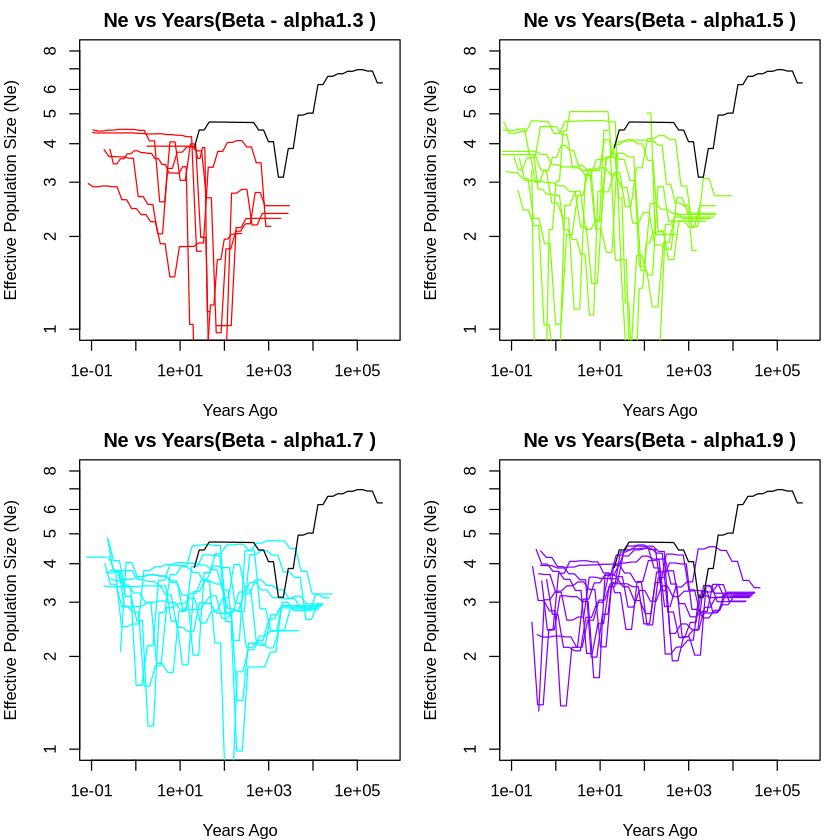

In [19]:
# # Define the number of rows and columns for subplots based on the number of alpha values
num_alphas <- length(alpha_values)
rows <- ceiling(sqrt(num_alphas))  # Number of rows for the plot grid
cols <- ceiling(num_alphas / rows) # Number of columns for the plot grid

# Set up layout for multiple subplots
par(mfrow = c(rows, cols), mar = c(4, 4, 2, 1),bg="white")  # Adjust margins for subplot spacing

# Loop over each alpha value and create individual plots
for (alpha in alpha_values) {
  # Set up empty plot for the current alpha
  plot(NULL, xlim = c(0.1, 500000), ylim = c(1, 8),
       xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
       main = paste("Ne vs Years(Beta -", alpha, ")"),
       log = "xy")

  # Filter Beta data frames by the current alpha
  beta_lines <- lapply(individual_data_frames[[4]]$beta, function(df) {
    if (df$alpha[1] == alpha) {
      return(df)
    } else {
      return(NULL)
    }
  })
  beta_lines <- Filter(Negate(is.null), beta_lines)  # Remove NULL entries

  # Plot each line for the current alpha
  for (i in seq_along(beta_lines)) {
    lines(beta_lines[[i]]$years_ago, beta_lines[[i]]$Ne, 
          type = "l", lty = 1, col = colors[which(alpha_values == alpha)])
  }
  # Plot the overall demography line in black for each subplot
    lines(demography_data$years_ago, demography_data$Ne, 
        type = "l", lty = 1, col = "black") 
}

# Reset layout to default for any further plots
par(mfrow = c(1, 1))


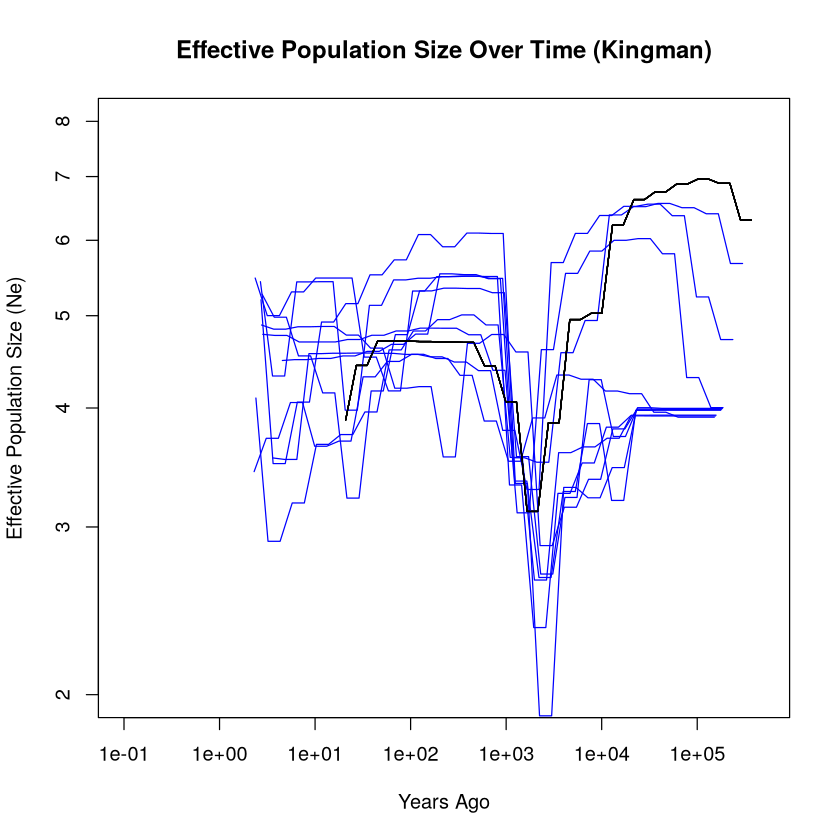

In [65]:


# Plot setup for Kingman lines
plot(NULL, xlim = c(0.1, 500000), ylim = c(2, 8),
     xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
     main = "Effective Population Size Over Time (Kingman)",
     log = "xy")

# Plot Kingman lines for all items in individual_data_frames
for (i in seq_along(individual_data_frames[[4]]$kingman)) {
  lines(individual_data_frames[[4]]$kingman[[i]]$years_ago, 
        individual_data_frames[[4]]$kingman[[i]]$Ne, 
        type = "l", lty = 1, col = "blue")
# Plot the overall demography line in black for each subplot
  lines(demography_data$years_ago, demography_data$Ne, 
        type = "l", lty = 1, col = "black") 
}



1e-10

In [29]:
# Constants
mu <- 1e-10
gen_times <-0.16

# Initialize sub-lists for 'kingman' and 'beta' within each main entry
individual_data_frames[[5]] <- list(kingman = list(), beta = list())
  
# Process 'kingman' files
for (j in seq_along(rds_files_list[[1]]$kingman)) {
    kingman_dir <- rds_files_list[[1]]$kingman[j]
    
    if (file.exists(kingman_dir)) {
      data_esmc <- readRDS(kingman_dir)  # Read the .rds file
      
      # Perform calculations
      Ne_t <- data_esmc$Xi
      Ne <- mean(data_esmc$mu / mu)
      #print(Ne_t)
      # Calculate years ago and log10 of Ne
      data_esmc$years_ago <- data_esmc$Tc * Ne * gen_times
      data_esmc$Ne <- log10(Ne_t * Ne)
      
      # Create a unique label using both j and file_base_name
      file_base_name <- basename(kingman_dir)
      label <- paste0(j, "_", file_base_name)
      
      # Store the results in a data frame using the unique label
      individual_data_frames[[5]]$kingman[[label]] <- data.frame(
        years_ago = data_esmc$years_ago,
        Ne = data_esmc$Ne
      )
    } else {
      warning(paste("Kingman directory does not exist:", kingman_dir))
    }
  }
  
  # Process 'beta' files
  for (j in seq_along(rds_files_list[[1]]$beta)) {
    beta_dir <- rds_files_list[[1]]$beta[j]
    print(beta_dir)
    path_components <- unlist(strsplit(beta_dir, "/"))
    # Extract the second last component
    second_last_component <- path_components[length(path_components) - 1]
    if (file.exists(beta_dir)) {
      data_esmc <- readRDS(beta_dir)  # Read the .rds file

      # Perform calculations
      Ne_t <- data_esmc$Xi
      Ne <- mean(data_esmc$mu / mu)
      
      # Calculate years ago and log10 of Ne
      data_esmc$years_ago <- data_esmc$Tc * Ne * gen_times
      data_esmc$Ne <- log10(Ne_t * Ne)
      #print(Ne_t)
      # Create a unique label using both j and file_base_name
      file_base_name <- basename(beta_dir)
      label <- paste0(j, "_",file_base_name)
      # Store the results in a data frame using the unique label
      individual_data_frames[[5]]$beta[[label]] <- data.frame(
        years_ago = data_esmc$years_ago,
        Ne = data_esmc$Ne,
        alpha=as.character(second_last_component)
      )
    } else {
      warning(paste("Beta directory does not exist:", beta_dir))
    }
}


[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-10/alpha1.5/Beta_bottleneck_rep5_m1e-10_ratio999.9999999999999_rs1525230.vcf.rds"
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-10/alpha1.5/Beta_bottleneck_rep7_m1e-10_ratio999.9999999999999_rs1525232.vcf.rds"
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-10/alpha1.7/Beta_bottleneck_rep0_m1e-10_ratio999.9999999999999_rs1525225.vcf.rds"
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-10/alpha1.7/Beta_bottleneck_rep2_m1e-10_ratio999.9999999999999_rs1525227.vcf.rds"
[1] "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/Sims_for_eSMC_SMBC/eSMC_out/esmc2_beta/m1e-10/alpha1.7/Beta_bottleneck_rep3_m1e-10_ratio999.9999999999999_rs15

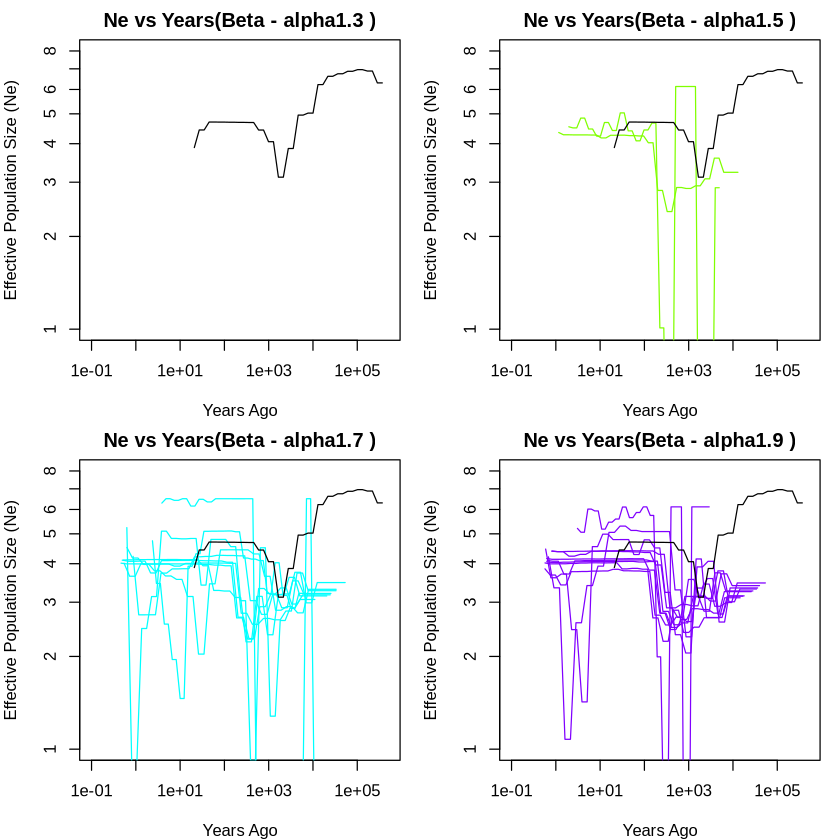

In [21]:
# # Define the number of rows and columns for subplots based on the number of alpha values
num_alphas <- length(alpha_values)
rows <- ceiling(sqrt(num_alphas))  # Number of rows for the plot grid
cols <- ceiling(num_alphas / rows) # Number of columns for the plot grid

# Set up layout for multiple subplots
par(mfrow = c(rows, cols), mar = c(4, 4, 2, 1), bg="white")  # Adjust margins for subplot spacing

# Loop over each alpha value and create individual plots
for (alpha in alpha_values) {
  # Set up empty plot for the current alpha
  plot(NULL, xlim = c(0.1, 500000), ylim = c(1, 8),
       xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
       main = paste("Ne vs Years(Beta -", alpha, ")"),
       log = "xy")

  # Filter Beta data frames by the current alpha
  beta_lines <- lapply(individual_data_frames[[5]]$beta, function(df) {
    if (df$alpha[1] == alpha) {
      return(df)
    } else {
      return(NULL)
    }
  })
  beta_lines <- Filter(Negate(is.null), beta_lines)  # Remove NULL entries

  # Plot each line for the current alpha
  for (i in seq_along(beta_lines)) {
    lines(beta_lines[[i]]$years_ago, beta_lines[[i]]$Ne, 
          type = "l", lty = 1, col = colors[which(alpha_values == alpha)])
  }
  # Plot the overall demography line in black for each subplot
    lines(demography_data$years_ago, demography_data$Ne, 
        type = "l", lty = 1, col = "black") 
}

# Reset layout to default for any further plots
par(mfrow = c(1, 1))


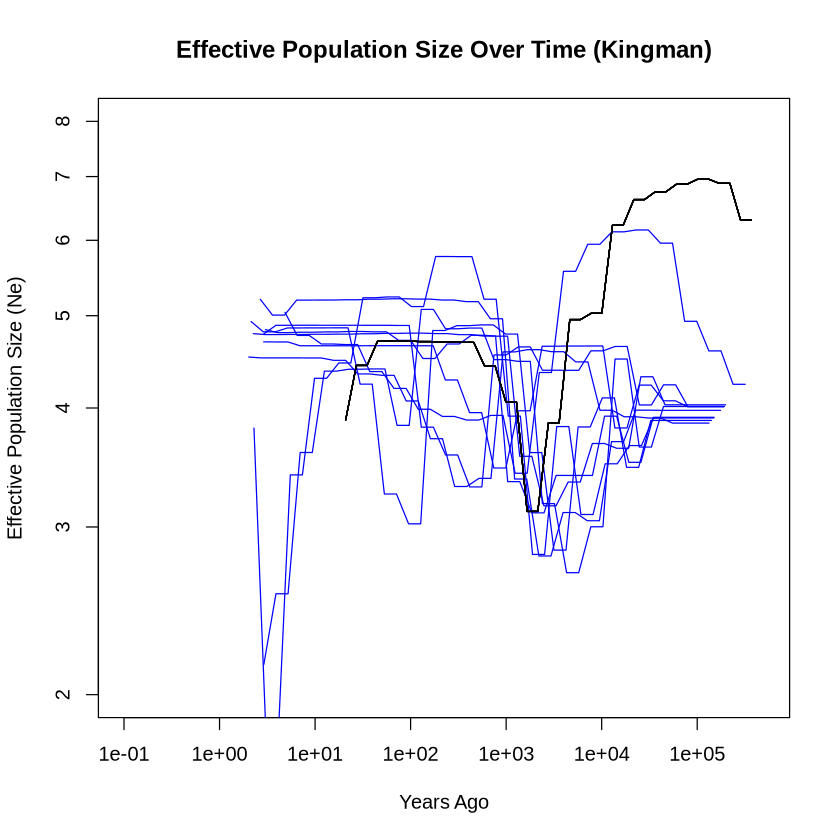

In [25]:

par(bg="white")
# Plot setup for Kingman lines
plot(NULL, xlim = c(0.1, 500000), ylim = c(2, 8),
     xlab = "Years Ago", ylab = "Effective Population Size (Ne)",
     main = "Effective Population Size Over Time (Kingman)",
     log = "xy")

# Plot Kingman lines for all items in individual_data_frames
for (i in seq_along(individual_data_frames[[5]]$kingman)) {
  lines(individual_data_frames[[5]]$kingman[[i]]$years_ago, 
        individual_data_frames[[5]]$kingman[[i]]$Ne, 
        type = "l", lty = 1, col = "blue")
# Plot the overall demography line in black for each subplot
  lines(demography_data$years_ago, demography_data$Ne, 
        type = "l", lty = 1, col = "black") 
}

